## NEURONpyxl Tutorial
*Author:* Uri Dickman

This tutorial is designed to introduce using NEURONpyxl through the Python API.

*After compiling the mod files for a particular simulation, you may need to restart the Jupyter kernel.*

#### 1. Running NEURONpyxl from the Command Line

First, let's run a basic simulation using NEURONpyxl from the command line. Copy and paste the following commands:

First, generate and compile the mod files:
- `neuronpyxl -f gen_mods --file sheets/fig5-fig9.xlsx`

Next, run a simulation called "excitability" from the sheet "sheets/fig5-fig9.xlsx" that is 9000 ms long with an relaxation time of 1000 ms before recording data, saving the data into ./Data/example1
- `neuronpyxl -f run_sim --file sheets/fig5-fig9.xlsx --name excitability --duration 9000 --teq 1000 --folder example1`

See the README.md for a full list of command-line options.

Read the resulting file into Pandas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

filepath = "./Data/example1/excitability_data.h5" # path to the data file that was generated
file = pd.HDFStore(filepath) # Read in the data file
keys = file.keys()
print(f"File {filepath} has keys: {[k.replace("/","") for k in keys]}") # Print keys in the data file

File ./Data/example1/excitability_data.h5 has keys: ['B4']


In [3]:
B4_data = file["B4"] # Get the data corresponding to the B4 neuron
B4_data # View all data corresponding to the B4 neuron

,V,I_can,I_k,I_ka,I_kcaf,I_kcas,I_na,I_leak,I_cap,cai,I_app,t
0,-62.345983,-2.653341e-11,0.002825,0.771711,5.684559e-14,4.256801e-09,-0.038677,-0.734598,-0.001261,3.802075e-15,0.0,0.026698
1,-62.345990,-1.768010e-10,0.002825,0.771712,5.684517e-14,4.256882e-09,-0.038677,-0.734599,-0.001261,3.801025e-15,0.0,0.062147
2,-62.345996,-5.846480e-12,0.002825,0.771712,5.684463e-14,4.256963e-09,-0.038677,-0.734600,-0.001261,3.802892e-15,0.0,0.097596
3,-62.346002,-4.010661e-10,0.002825,0.771712,5.684434e-14,4.257045e-09,-0.038677,-0.734600,-0.001261,3.801772e-15,0.0,0.133045
4,-62.346005,-2.977924e-10,0.002825,0.771713,5.684417e-14,4.257075e-09,-0.038677,-0.734600,-0.001261,3.802124e-15,0.0,0.146484
...,...,...,...,...,...,...,...,...,...,...,...,...
247735,-62.659302,-8.551569e-10,0.002446,0.746567,4.537899e-14,5.120506e-02,-0.034876,-0.765930,0.000588,3.540322e-15,0.0,8999.799557
247736,-62.659301,-6.088902e-10,0.002446,0.746567,4.537884e-14,5.120486e-02,-0.034876,-0.765930,0.000588,3.541137e-15,0.0,8999.812519
247737,-62.659300,-5.503920e-10,0.002446,0.746567,4.537873e-14,5.120465e-02,-0.034876,-0.765930,0.000588,3.541149e-15,0.0,8999.825482
247738,-62.659295,-4.163446e-10,0.002446,0.746568,4.537818e-14,5.120374e-02,-0.034876,-0.765930,0.000588,3.540807e-15,0.0,8999.882829


Text(0.5, 0.98, 'Simple B4 Neuron Simulation')

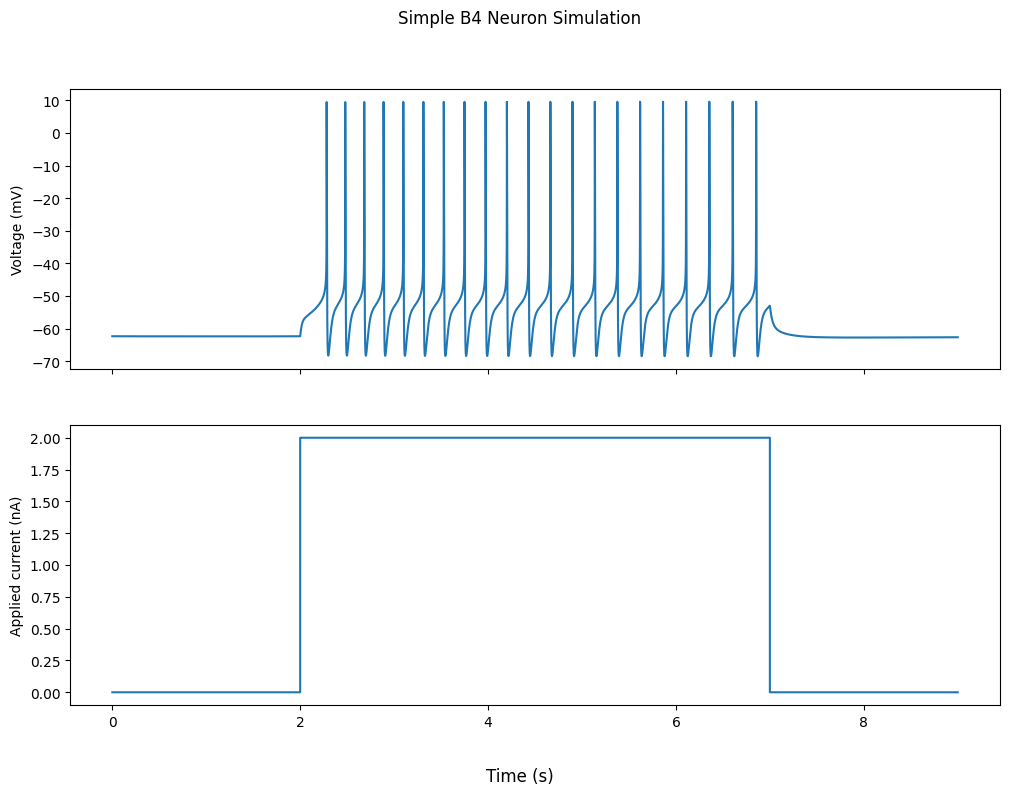

In [6]:
# Plot the voltage data
t = B4_data["t"]/1000
fig,axs = plt.subplots(2,1,figsize=(12,8),sharex=True)
axs[0].plot(t,B4_data["V"])
axs[0].set_ylabel("Voltage (mV)")

axs[1].plot(t,B4_data["I_app"])
axs[1].set_ylabel("Applied current (nA)")
fig.supxlabel("Time (s)")

fig.suptitle("Simple B4 Neuron Simulation")

#### 2. Loading and running an Excel model

It is also possible to run NEURONpyxl from Python directly.
This is useful for customizing your simulations, doing parameter sweeps, and recording additional state variables.

Let's start by running the exact same simulation from Example 1.

Generate and compile the mod files again rom the command line
- `neuronpyxl -f gen_mods --file sheets/fig5-fig9.xlsx`

In [1]:
from neuronpyxl import network
import matplotlib.pyplot as plt
import pandas as pd

filepath = "./sheets/fig5-fig9.xlsx"
nw = network.Network(params_file=filepath, # path to Excel model file
                            sim_name="excitability", # Name of .smu sheet to run
                            dt=-1, # Constant timestep if > 0
                            integrator=2, # Integration method, uses CVODE with this option combined with dt=-1
                            atol=1e-5, # absolute error tolerance
                            eq_time=1000, # Relaxation time before recording
                            simdur=9000, # Simulation duration
                            noise=None, # Noise parameters (not used here)
                            seed=False # Set deterministic seeds for noise (not used here)
                            )

Added Cell(gid=1, name=B4) to the network.
Loading simulation parameters...


In [2]:
# Run simulation
nw.run()

Running simulation...


In [ ]:
# Get data from the Network

B4_data = pd.DataFrame(nw.get_cell_data("B4"))
B4_data

,V,I_can,I_k,I_ka,I_kcaf,I_kcas,I_na,I_leak,I_cap,cai,I_app,t
0,-62.345983,-2.653341e-11,0.002825,0.771711,5.684559e-14,4.256801e-09,-0.038677,-0.734598,-0.001261,3.802075e-15,0.0,0.026698
1,-62.345990,-1.768010e-10,0.002825,0.771712,5.684517e-14,4.256882e-09,-0.038677,-0.734599,-0.001261,3.801025e-15,0.0,0.062147
2,-62.345996,-5.846480e-12,0.002825,0.771712,5.684463e-14,4.256963e-09,-0.038677,-0.734600,-0.001261,3.802892e-15,0.0,0.097596
3,-62.346002,-4.010661e-10,0.002825,0.771712,5.684434e-14,4.257045e-09,-0.038677,-0.734600,-0.001261,3.801772e-15,0.0,0.133045
4,-62.346005,-2.977924e-10,0.002825,0.771713,5.684417e-14,4.257075e-09,-0.038677,-0.734600,-0.001261,3.802124e-15,0.0,0.146484
...,...,...,...,...,...,...,...,...,...,...,...,...
247735,-62.659302,-8.551569e-10,0.002446,0.746567,4.537899e-14,5.120506e-02,-0.034876,-0.765930,0.000588,3.540322e-15,0.0,8999.799557
247736,-62.659301,-6.088902e-10,0.002446,0.746567,4.537884e-14,5.120486e-02,-0.034876,-0.765930,0.000588,3.541137e-15,0.0,8999.812519
247737,-62.659300,-5.503920e-10,0.002446,0.746567,4.537873e-14,5.120465e-02,-0.034876,-0.765930,0.000588,3.541149e-15,0.0,8999.825482
247738,-62.659295,-4.163446e-10,0.002446,0.746568,4.537818e-14,5.120374e-02,-0.034876,-0.765930,0.000588,3.540807e-15,0.0,8999.882829


Text(0.5, 0.98, 'B4 Neuron')

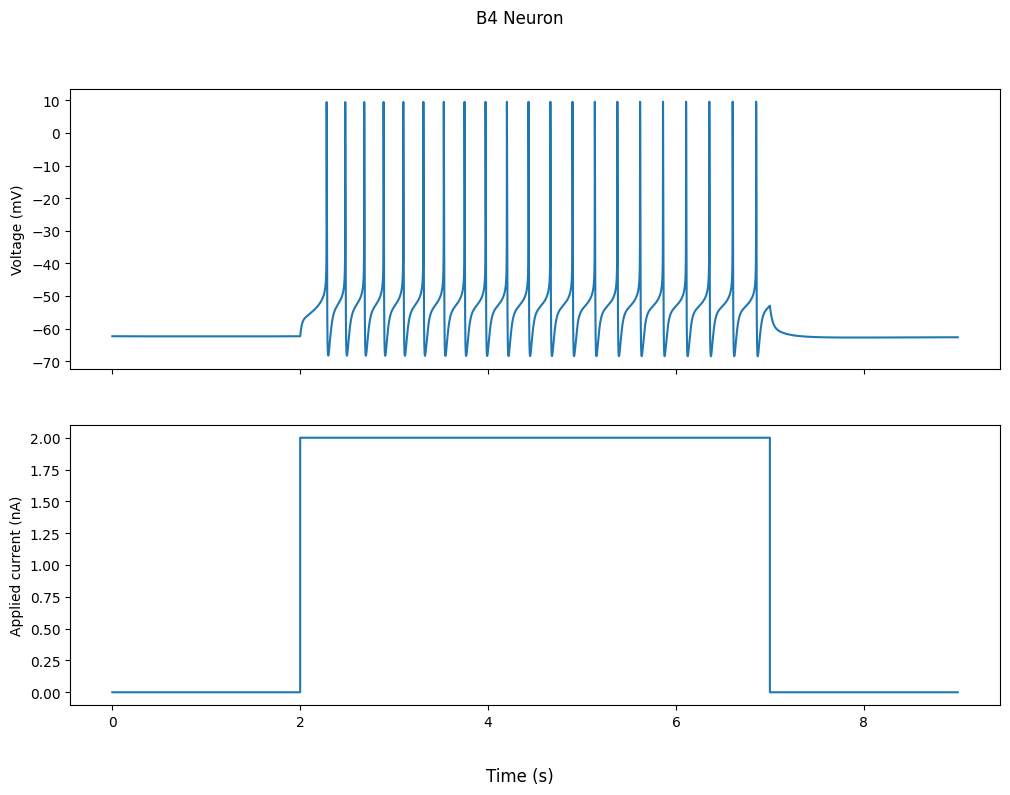

In [5]:
# Plot the voltage data
t = B4_data["t"] / 1000

fig,axs = plt.subplots(2,1,figsize=(12,8),sharex=True)
axs[0].plot(t,B4_data["V"])
axs[0].set_ylabel("Voltage (mV)")

axs[1].plot(t,B4_data["I_app"])
axs[1].set_ylabel("Applied current (nA)")

fig.supxlabel("Time (s)")

fig.suptitle("B4 Neuron")

Let's now run a noisy simulation of B4 neuron spikes.

This is using the same spreadsheet as the previous simulation so we don't need to recompile the mod files.

In [ ]:
nw_noise = network.Network(params_file=filepath,
                            sim_name="excitability",
                            dt=-1,
                            integrator=2,
                            atol=1e-5,
                            eq_time=1000,
                            simdur=9000,
                            noise=(250,1e-2,6), # Frequency (Hz), synaptic weight (uS), time constant (ms)
                            seed=True # Set deterministic seed (doesn't seem to be working at the moment...)
                            )

Added Cell(gid=2, name=B4) to the network.
Loading simulation parameters...


In [8]:
# Run simulation
nw_noise.run()

Running simulation...


In [ ]:
# Get data from the Network
B4_noisy_data = pd.DataFrame(nw_noise.get_cell_data("B4"))
B4_noisy_data

,V,I_can,I_k,I_ka,I_kcaf,I_kcas,I_na,I_leak,I_cap,cai,I_app,t,noise
0,-61.639408,-3.361308e-10,0.003668,0.896486,6.775629e-14,5.919087e-09,-0.048859,-0.663941,-0.057055,3.360123e-15,0.0,0.002736,-0.130298
1,-61.639974,-4.350470e-10,0.003669,0.896388,6.774511e-14,5.918496e-09,-0.048854,-0.663997,-0.058356,3.359599e-15,0.0,0.070537,-0.128850
2,-61.640551,-2.151623e-10,0.003669,0.896287,6.773335e-14,5.917890e-09,-0.048847,-0.664055,-0.059636,3.360657e-15,0.0,0.138338,-0.127417
3,-61.640697,-2.754559e-10,0.003669,0.896262,6.773045e-14,5.917737e-09,-0.048846,-0.664070,-0.059955,3.360350e-15,0.0,0.155289,-0.127060
4,-61.640843,-2.787009e-10,0.003669,0.896237,6.772749e-14,5.917583e-09,-0.048844,-0.664084,-0.060273,3.360304e-15,0.0,0.172239,-0.126704
...,...,...,...,...,...,...,...,...,...,...,...,...,...
255318,-63.671098,-3.543237e-11,0.001659,0.613793,1.223404e-13,3.316144e-02,-0.025043,-0.867110,-0.083420,1.961918e-14,0.0,8999.788666,0.326959
255319,-63.671568,-3.471538e-09,0.001659,0.613712,1.223186e-13,3.315484e-02,-0.025037,-0.867157,-0.081114,1.965676e-14,0.0,8999.828637,0.324782
255320,-63.672024,-3.161444e-10,0.001658,0.613632,1.222978e-13,3.314841e-02,-0.025032,-0.867202,-0.078825,1.969056e-14,0.0,8999.868608,0.322620
255321,-63.672468,-1.440989e-09,0.001658,0.613554,1.222795e-13,3.314215e-02,-0.025026,-0.867247,-0.076553,1.970710e-14,0.0,8999.908579,0.320472


Text(0.5, 0.98, 'Noisy B4 Neuron')

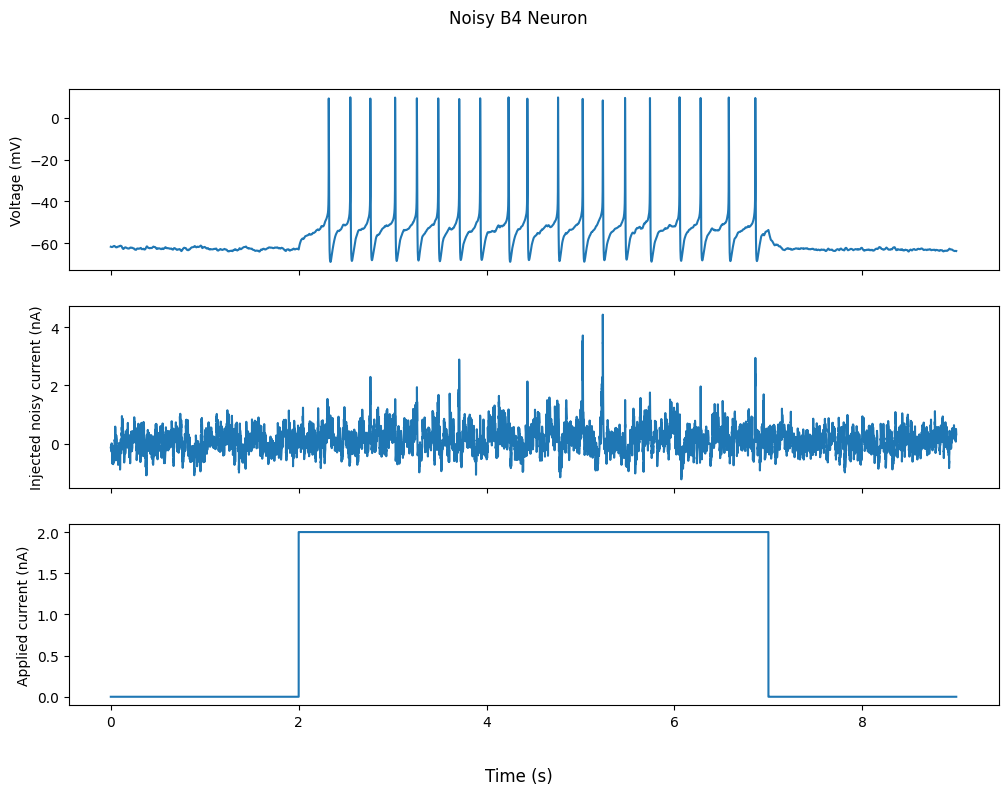

In [13]:
# Plot the voltage data
t = B4_noisy_data["t"] / 1000

fig,axs = plt.subplots(3,1,figsize=(12,8),sharex=True)
axs[0].plot(t,B4_noisy_data["V"]) # Membrane voltage
axs[0].set_ylabel("Voltage (mV)")

axs[1].plot(t,B4_noisy_data["noise"]) # Injected noisy current
axs[1].set_ylabel("Injected noisy current (nA)")

axs[2].plot(t,B4_noisy_data["I_app"]) # Applied current
axs[2].set_ylabel("Applied current (nA)")

fig.supxlabel("Time (s)")

fig.suptitle("Noisy B4 Neuron")

#### 3. Data Structures in NEURONpyxl

We can record more from NEURON than just the membrane currents and voltages in each cell. 
We also have access to the state variables, which are stored in several data structures in NEURON, and can be accessed through the Python API.

#### Aside

You can access the reference and values to state variables using the prefix \_ref\_ before the name of the state variable.

State variables in distributed NEURON mechanisms are given by *var-name_mech-name*.
For example, to get the reference to the activation m from the default hh mechanism in NEURON, you would do

In [16]:
from neuron import h

sec = h.Section() # Create neuron section
sec.insert('hh') # Insert default Hodgkin-Huxley mechanism, for example
print("Pointer reference to state variable: ", sec(0.5)._ref_m_hh) # Access hoc pointer from location 0.5

# To get the value of the any variable, including a parameter you don't include the _ref_ prefix.

print("Value of state variable: ", sec(0.5).m_hh) # Access value of m state variable from location 0.5

Pointer reference to state variable:  <pointer to hoc scalar 0>
Value of state variable:  0.0


Let's now run a simulation with 3 cells connected by plastic synapses.

Compile the mod files again rom the command line
- `neuronpyxl -f gen_mods --file sheets/fig7.xlsx`

In [1]:
from neuron import h
from neuronpyxl import network
import matplotlib.pyplot as plt

filepath = "./sheets/fig7.xlsx"
nw = network.Network(params_file=filepath,
                            sim_name="synapse",
                            dt=-1,
                            integrator=2,
                            atol=1e-5,
                            eq_time=2500,
                            simdur=5000,
                            noise=None,
                            seed=False
                            )

nrows =    Unnamed: 0 Unnamed: 1 Unnamed: 2   File leak Unnamed: 5 Na Unnamed: 7  \
3          B          B        NaN  0.003  0.1        -70  8          3   

  Unnamed: 8 Unnamed: 9  ... Unnamed: 293 Unnamed: 294 Unnamed: 295  \
3         50          0  ...          NaN          NaN          NaN   

  Unnamed: 296 Unnamed: 297 Unnamed: 298 Unnamed: 299 Unnamed: 300  \
3          NaN          NaN          NaN          NaN          NaN   

  Unnamed: 301 Unnamed: 302  
3          NaN          NaN  

[1 rows x 303 columns]
Added Cell(gid=1, name=A) to the network.
Added Cell(gid=2, name=B) to the network.
Added Cell(gid=3, name=C) to the network.
Loading simulation parameters...


Notice that cell B has facilitation by the sodium pool in cell A.

Let's record the sodium activation and concentration in cell A and the time-dependent synaptic activation in cell B.

In NEURON, state variables are recorded as hoc pointers, and can be accessed from a neuron segment.

In [2]:
# nw has a 'cells' dictionary which maps the cell names to Cell objects (see cell.py)
segA = nw.cells["A"].section(0.5) # Record from the neuron segment located at 0.5 (since these are point cells)
# nw also as a 'chemical_synapses' dictionary which has the structure: synapse speed -> presynaptic cell -> postsynaptic cell -> synapses
synw = nw.chemical_synapses["fast"]["A"]["B"]["synapse"]

Ana_rec = h.Vector().record(segA._ref_A_neuronpyxl_na) # Record sodium activation
nai_rec = h.Vector().record(segA._ref_nai) # Record internal sodium concentration
Atsyn_rec = h.Vector().record(synw._ref_At) # Record time-dependent activation in the synapse
t_rec = h.Vector().record(h._ref_t) # Record time

In [3]:
nw.run(record_none=True) # Only interested in the recordings above, so we don't record anything else to conserve memory

Running simulation...


In [7]:
# The following is done automatically in NEURONpyxl if you are using the data reported directly from
# nw.get_cell_data() or nw.get_synaptic_current_data()

# Convert to numpy array and adjust for eq_time (nw.noise_eq_time is 0 if there is no noise)
t = t_rec.as_numpy()
mask = t > nw.eq_time + nw.noise_eq_time

t = (t[mask] - t[mask][0]) / 1000 # Only keep the data after the equilibration step
Ana = Ana_rec.as_numpy()[mask]
nai = nai_rec.as_numpy()[mask]
Atsyn = Atsyn_rec.as_numpy()[mask]

Text(0.5, 0.01, 'Time (s)')

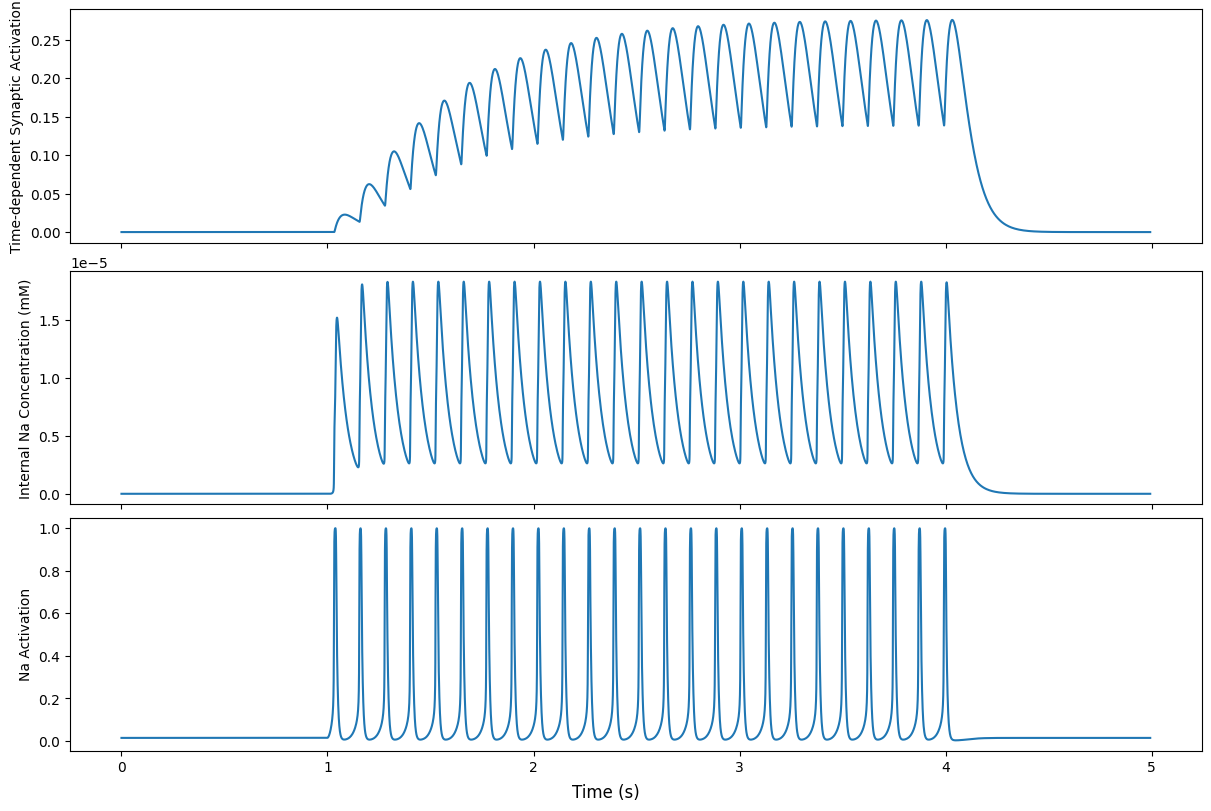

In [8]:
# Plot the voltage data
fig,axs = plt.subplots(3,1,figsize=(12,8),sharex=True,constrained_layout=True)
axs[0].plot(t,Atsyn)
axs[0].set_ylabel("Time-dependent Synaptic Activation")

axs[1].plot(t,nai)
axs[1].set_ylabel("Internal Na Concentration (mM)")

axs[2].plot(t,Ana)
axs[2].set_ylabel("Na Activation")

fig.supxlabel("Time (s)")

Relevant data structures in NEURON include:
- `nw.cells`: Dictionary with key map cell name -> Cell object (see cell.py)
- `nw.chemical_synapses`: Dictionary with key map speed (fast or slow) -> presynaptic neuron -> postsynaptic neuron -> h.neuronpyxl_CS ("synapse") and h.NetCon object ("netcon")
- `nw.electrical_synapses`: Dictionary with key map presynaptic neuron -> postsynaptic neuron -> h.neuronpyxl_ES object
- `nw.current_clamps`: Dictionary with key map cell name -> list of h.IClamp objects

Other data structures are internal and probably don't need to be used. If you want to access them, see the source code itself.

#### 4. Parameter Sweeps

Let's return to the simulation of the B4 neuron, and let's say we are interested in the effect of the level of depolarization on spike frequency.

This requires measuring the spike frequency for multiple values of applied current.

First, generate and compile the mod files
- `neuronpyxl -f gen_mods --file ./sheets/fig5-fig9.xlsx`

In [1]:
from neuron import h
from neuronpyxl import network
import numpy as np
import matplotlib.pyplot as plt

# NEURONpyxl already adds a current clamp if we are running 'excitability.smu' in the spreadsheet
# But let's use the 'nostim.smu' sheet and add our own using the nw.attach_iclamp() function
filepath = "./sheets/fig5-fig9.xlsx"
nw = network.Network(params_file=filepath,
                            sim_name="nostim",
                            dt=-1,
                            integrator=2,
                            atol=1e-5,
                            eq_time=1000,
                            simdur=9000,
                            noise=None,
                            seed=False
                            )

Added Cell(gid=1, name=B4) to the network.
Loading simulation parameters...


In [2]:
# Define a function to compute spike frequency
def mean_spike_freq(t,v,spike_thresh=-10): # Function to detect spikes and return spike frequency
    crossings = np.where((v[:-1] < spike_thresh) & (v[1:] >= spike_thresh))[0] # Where each spike crosses spike_thresh upwards
    spike_timing = np.diff(t[crossings]) # time between spikes
    if len(spike_timing) == 0: # 0 Hz if no spikes
        return 0
    return 1000 / np.mean(spike_timing) # Mean frequency in Hz

In [3]:
ic = nw.attach_iclamp(name="B4",delay=2000,dur=5000) # Leave the amplitude as None since we will change it later

currents = np.linspace(0,15,num=20) # List of different current amplitudes
frequencies = np.zeros_like(currents) # List of frequencies to populate

for i,amp in enumerate(currents): # Iterate through current values
    ic.amp = amp # set the current amplitude
    print(f"Amplitude set to {ic.amp} nA")
    
    nw.run(voltage_only=True) # Run the simulation, recording only the membrane voltage
    data = nw.get_cell_data("B4")

    f = mean_spike_freq(data["t"],data["V"])
    frequencies[i] = f

Amplitude set to 0.0 nA
Running simulation...
Amplitude set to 0.7894736842105263 nA
Running simulation...
Amplitude set to 1.5789473684210527 nA
Running simulation...
Amplitude set to 2.3684210526315788 nA
Running simulation...
Amplitude set to 3.1578947368421053 nA
Running simulation...
Amplitude set to 3.947368421052632 nA
Running simulation...
Amplitude set to 4.7368421052631575 nA
Running simulation...
Amplitude set to 5.526315789473684 nA
Running simulation...
Amplitude set to 6.315789473684211 nA
Running simulation...
Amplitude set to 7.105263157894737 nA
Running simulation...
Amplitude set to 7.894736842105264 nA
Running simulation...
Amplitude set to 8.68421052631579 nA
Running simulation...
Amplitude set to 9.473684210526315 nA
Running simulation...
Amplitude set to 10.263157894736842 nA
Running simulation...
Amplitude set to 11.052631578947368 nA
Running simulation...
Amplitude set to 11.842105263157896 nA
Running simulation...
Amplitude set to 12.631578947368421 nA
Running 

Text(0, 0.5, 'Spike frequency (Hz)')

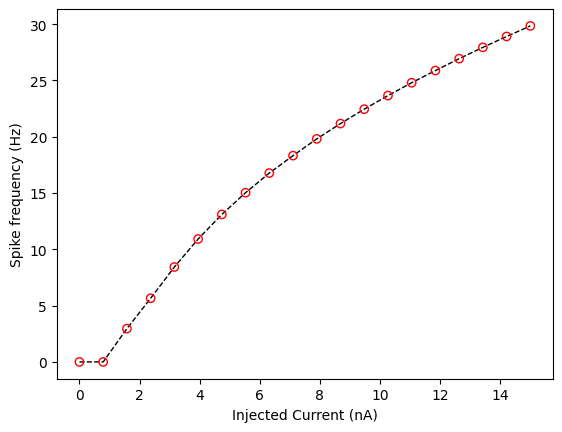

In [4]:
plt.plot(currents,frequencies,linestyle="dashed",color="black",linewidth=1)
plt.scatter(currents,frequencies,zorder=2,facecolor="none",edgecolors="red")
plt.xlabel("Injected Current (nA)")
plt.ylabel("Spike frequency (Hz)")

#### 5. Variable Current Stimulus

Now, let's show how to play a variable stimulating current into a NEURON section.

First, generate and compile the mod files
- `neuronpyxl -f gen_mods --file ./sheets/fig5-fig9.xlsx`

In [5]:
from neuron import h
from neuronpyxl import network
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

filepath = "./sheets/fig5-fig9.xlsx"
nw = network.Network(params_file=filepath,
                            sim_name="nostim",
                            dt=-1,
                            integrator=2,
                            atol=1e-5,
                            eq_time=1000,
                            simdur=10000,
                            noise=None,
                            seed=False
                            )

Added Cell(gid=2, name=B4) to the network.
Loading simulation parameters...


In [6]:
ic = nw.attach_iclamp(name="B4",delay=0,dur=1e9) 

In [ ]:
# Define sinusoidal current with frequency 0.5 Hz
f = 0.5 # Hz
w = 2 * np.pi * f / 1000 # angular frequency in rad/ms
A = 2 # Current amplitude
t = np.linspace(nw.eq_time,nw.simdur+nw.eq_time,10000) # Need to account for relaxation time
sin_current = A * np.sin(w*t) + A

# Convert time series to hoc Vector
tvec = h.Vector(t)
ivec = h.Vector(sin_current)
# Play current vector into IClamp amplitude hoc pointer (3rd argument => NEURON interpolates to the internal timestep)
ivec.play(ic._ref_amp, tvec, True)

In [18]:
nw.run()
B4_data = pd.DataFrame(nw.get_cell_data("B4"))

Running simulation...


Text(0.5, 0.98, 'B4 Neuron with Oscillatory Current')

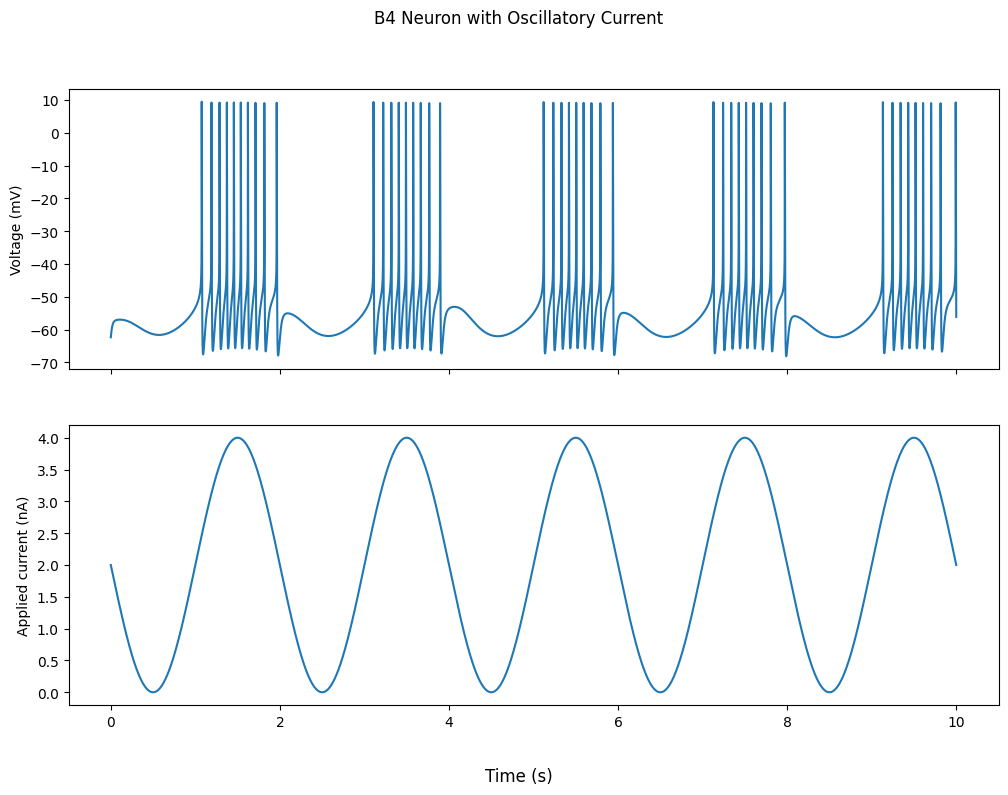

In [20]:
# Plot the voltage data
t = B4_data["t"] / 1000
fig,axs = plt.subplots(2,1,figsize=(12,8),sharex=True)
axs[0].plot(t,B4_data["V"])
axs[0].set_ylabel("Voltage (mV)")

axs[1].plot(t,B4_data["I_app"])
axs[1].set_ylabel("Applied current (nA)")

fig.supxlabel("Time (s)")

fig.suptitle("B4 Neuron with Oscillatory Current")

#### 6. Save State and Restore From State

Now, we are interested in restoring the state of a simulation from a certain point in time.

This is useful when applying a perturbation to a dynamical variable at a particular point in phase space, for example.

We will demonstrate this with the model which produces figure 7 in Dickman et. al.

Compile the mod files again rom the command line
- `neuronpyxl -f gen_mods --file sheets/fig7.xlsx`

In [1]:
from neuron import h
from neuronpyxl import network

filepath = "./sheets/fig7.xlsx"
nw = network.Network(params_file=filepath,
                            sim_name="synapse",
                            dt=-1,
                            integrator=2,
                            atol=1e-5,
                            eq_time=2500,
                            simdur=13000,
                            noise=None,
                            seed=False
                            )

Added Cell(gid=1, name=A) to the network.
Added Cell(gid=2, name=B) to the network.
Added Cell(gid=3, name=C) to the network.
Loading simulation parameters...


First, run the simulation up to the point where you want to save.

In [2]:
nw.run(voltage_only=True)
nw.save_state(filename="state.bin")

Running simulation...


Now, you should see a file called "state.bin" that was created in the current directory.

In order to restore to the state in that file, you *must* setup the entire NEURON memory structure **identically** to when you recorded the state previously.

This is very easy, as we can just **restart the Jupyter kernel** and copy the code from above, along with a few extra NEURON calls to make it all work.

In [1]:
from neuron import h
from neuronpyxl import network
import matplotlib.pyplot as plt

# Set up the simulation exactly the same as before
filepath = "./sheets/fig7.xlsx"
nw_restored = network.Network(params_file=filepath,
                            sim_name="synapse",
                            dt=-1,
                            integrator=2,
                            atol=1e-5,
                            eq_time=2500,
                            simdur=13000,
                            noise=None,
                            seed=False
                            )
nw_restored.record_voltage_only() # We also need to set up the recordings the same
h.stdinit()
nw_restored.restore_state(filename="state.bin")

Added Cell(gid=1, name=A) to the network.
Added Cell(gid=2, name=B) to the network.
Added Cell(gid=3, name=C) to the network.
Loading simulation parameters...


Now, the state has been restored so let's attach current clamp and see what happens. You can add anything you want to the model in this section.

In [ ]:
ic = nw_restored.attach_iclamp(name="B",delay=h.t-nw_restored.eq_time,dur=5000,amp=2)

Re-initialize CVODE and start the simulation where it left off.

In [3]:
h.cvode_active(1)
h.cvode.re_init()
h.continuerun(h.t + 5000) # Run for another 5000 ms

0.0

Text(0.5, 0, 'Time (ms)')

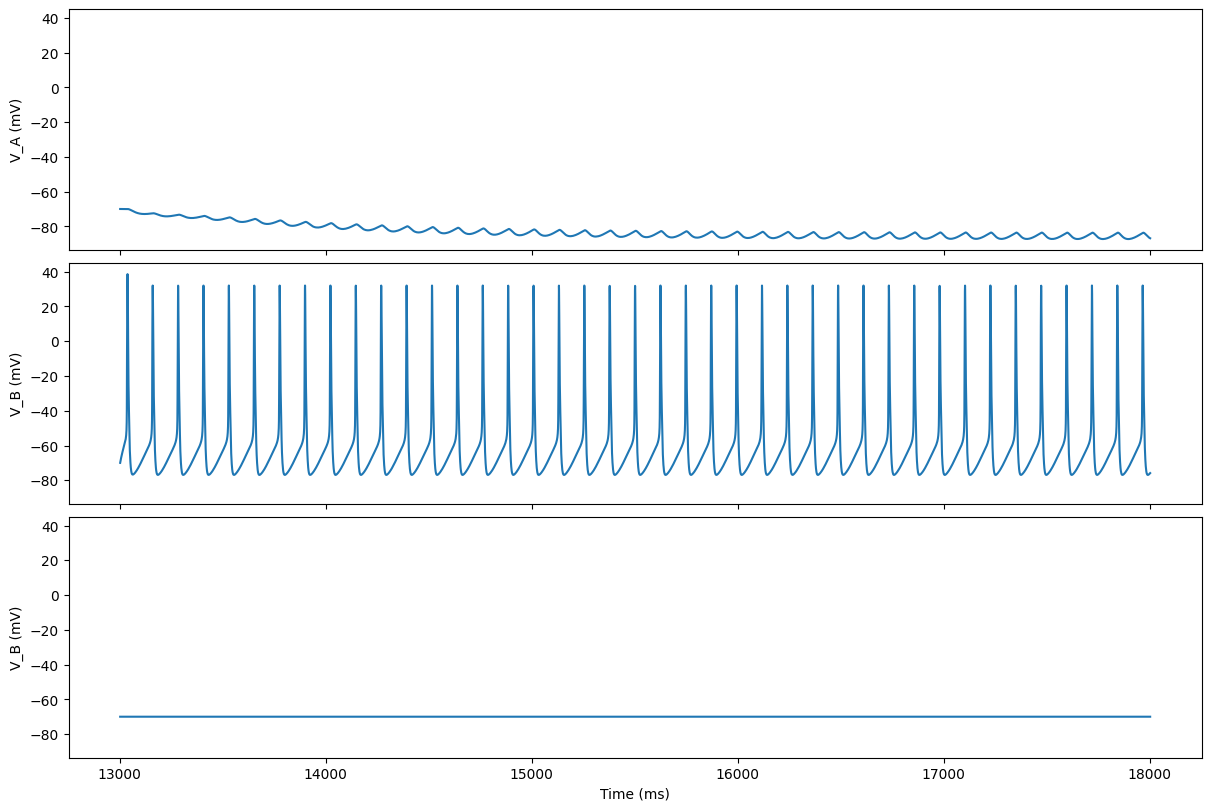

In [4]:
A_data = nw_restored.get_cell_data("A")
B_data = nw_restored.get_cell_data("B")
C_data = nw_restored.get_cell_data("C")
t = A_data["t"]

fig,axs = plt.subplots(3,1,figsize=(12,8),constrained_layout=True,sharex=True,sharey=True)
axs[0].plot(A_data["t"],A_data["V"])
axs[0].set_ylabel("V_A (mV)")
axs[1].plot(B_data["t"],B_data["V"])
axs[1].set_ylabel("V_B (mV)")
axs[2].plot(C_data["t"],C_data["V"])
axs[2].set_ylabel("V_B (mV)")
axs[2].set_xlabel("Time (ms)")